<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Termodinamica/Termo7_jm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Python 7:  **Atmosferas Planetarias**
<br>

### &nbsp; **Termodinamica:**

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*


<br>

___

<br>

In [ ]:
import numpy as np

Con antecedente la ecuacion de *Clasius-Clapeyron*: $ \frac{dP}{dT} = \frac{l}{T(v_f-v_f)}$. La **tropósfera** es la capa de la atmósfera planetaria que está en contacto con la superficie del planeta. Dependiendo del tipo de atmósfera del planeta, las relaciones entre la presión $P$ y la altitud $z$ están
por las siguientes ecuaciones: <br><br>


### **Atmosfera Isoterma:**

$$ P(z) = P_o \exp[-\frac{gz}{R^* T_o}]$$

> Donde $P_o$ presión a la altura $z = 0$ m, $T_o$ temperatura a $z = 0$ m, $g$ es la aceleración de la gravedad en el planeta,
$R^*$ es la constante especifica de los gases ideales (constante universal de los gases dividida por el peso molecular medio de la atmósfera). <br><br>



### **Atmosfera Adiabatica:**

$$ P(z) = P_0 [1-\frac{\Gamma_a(z-z_o)}{T_o}]^{\frac{g}{R^* \Gamma_a}} $$

> Donde $\Gamma_a = -\frac{dT}{dz}$ es el gradiente adiabatico. <br><br>






In [ ]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants

In [ ]:
planets = ['Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune', 'Titan']
components  = [[['CO2',(0.96)],['N2',(0.035)]],[['N2',(0.78)],['O2',(0.21)]],
               [['CO2',(0.953)],['N2',(0.027)]],[['H2',(0.864)],['He',(0.136)]],
               [['H2',(0.85)],['He',(0.14)]],[['H2',(0.85)],['He',(0.15)]],
               [['H2',(0.79)],['He',(0.21)]],[['N2',(0.65,0.98)],['Ar',(0.25,0)]]]

mu = [44.01,28.97,44.01,2.22,2.14,2.30,2.30,28.67]
R = np.array([0.19,0.29,0.19,3.75,3.89,3.61,3.61,0.29]) * 1000 # [g^-1] a [kg^-1]
cp = [0.85,1.00,0.83,12.36,14.01,13.01,13.01,1.04]
g = [8.89,9.80,3.74,24.25,10.00,8.80,11.10,1.35]
Gamma = np.array([10.50,9.80,4.50,2.00,0.70,0.70,0.85,1.30]) / 1000 # [km^-1] a [m^-1]
To = np.array([731,288,214,165,134,76,76,94])
Po = np.array([92,1.013,0.07,1.00,1.00,1.00,1.00,1.50])

table = {'Object':planets, 'Maincomponents':components,'μ':mu,
        'R*':R,'C_p':cp, 'g':g, 'Γ_a':Gamma,'T_o':To,'P_o':Po}

keys = {'Object','Maincomponents (%)','$μ$ (g mol$^{-1}$)',
        '$R^*$ (J g$^{-1}$K$^{-1}$)','$C_p$ (Jg$^{-1}$K$^{-1}$)',
        '$g$ (ms$^{-2}$)','$Γ$ (K Km $^{-1}$)','$T_o$ (K)','$P_o$ (bar)'}

df = pd.DataFrame(table)
df

,Object,Maincomponents,μ,R*,C_p,g,Γ_a,T_o,P_o
0,Venus,"[[CO2, 0.96], [N2, 0.035]]",44.01,190.0,0.85,8.89,0.01050,731,92.000
1,Earth,"[[N2, 0.78], [O2, 0.21]]",28.97,290.0,1.00,9.80,0.00980,288,1.013
2,Mars,"[[CO2, 0.953], [N2, 0.027]]",44.01,190.0,0.83,3.74,0.00450,214,0.070
3,Jupiter,"[[H2, 0.864], [He, 0.136]]",2.22,3750.0,12.36,24.25,0.00200,165,1.000
4,Saturn,"[[H2, 0.85], [He, 0.14]]",2.14,3890.0,14.01,10.00,0.00070,134,1.000
5,Uranus,"[[H2, 0.85], [He, 0.15]]",2.30,3610.0,13.01,8.80,0.00070,76,1.000
6,Neptune,"[[H2, 0.79], [He, 0.21]]",2.30,3610.0,13.01,11.10,0.00085,76,1.000
7,Titan,"[[N2, (0.65, 0.98)], [Ar, (0.25, 0)]]",28.67,290.0,1.04,1.35,0.00130,94,1.500


**7.29.** Diagramas PZ para ambas atmosferas en los planetas e interpretelas.





In [ ]:
# Rango de alturas
z = np.linspace(0,20000,2500) # [m]


# FUNCIONES DE PRESION ATMOSFERICA

def atm_isoterm( P_o, g, z, R, T_o ):  # Atm ISOTERMICA
  P = np.zeros( (len(df), len(z)))

  for i in range(len(z)):
    P[:,i] = P_o * np.exp( -g*z[i]/(R*T_o) ) # z arreglo

  return P


def atm_adiabatic( P_o, g, z, R, T_o, Γ_a ):  # Atm ADIABATICA
  P = np.zeros( (len(df), len(z)))

  for i in range(len(z)):
    P[:,i] = P_o * (1 - Γ_a*(z[i]-z[0]) /T_o)**(g/(R*Γ_a))  # z arreglo

  return P

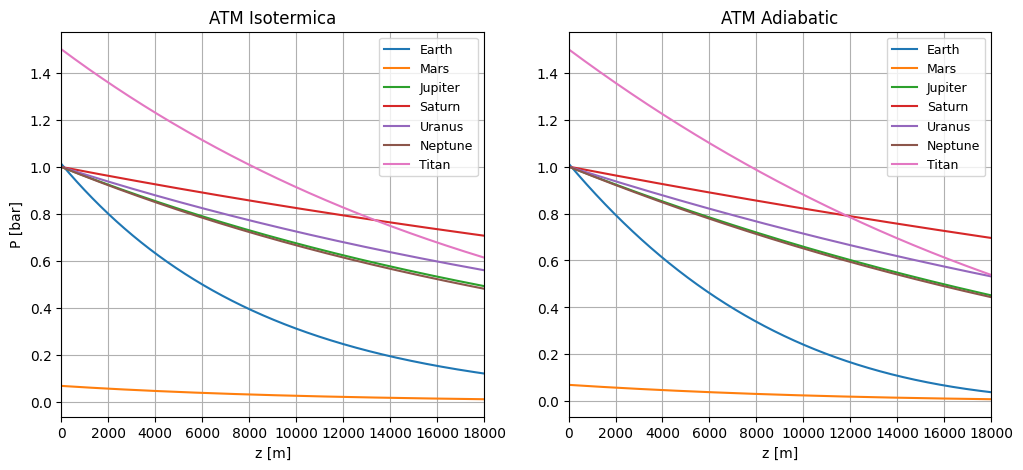

In [ ]:
# encontrando la presion
p_isot = atm_isoterm(df['P_o'], df['g'], z, df['R*'], df['T_o'])
p_adi = atm_adiabatic(df['P_o'], df['g'], z, df['R*'], df['T_o'], df['Γ_a'])


# grafica
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12,5))

ax[0].set_title('ATM Isotermica')
ax[0].set_xlabel('z [m]')
ax[0].set_ylabel('P [bar]')
ax[1].set_title('ATM Adiabatic')
ax[1].set_xlabel('z [m]')

for i in range(len(df)-1):
  ax[0].plot(z, p_isot[i+1,:], label=f'{planets[i+1]}')
  ax[1].plot(z, p_adi[i+1,:], label=f'{planets[i+1]}')

ax[1].legend(fontsize=9)
ax[1].set_xlim(0, z[-1])
ax[0].set_xlim(0, z[-1])
ax[1].grid()
ax[0].legend(fontsize=9)
ax[0].grid()

### **Interpretacion**
A pesar de no diferenciarse mucho, la Presion para el modelo de **atmosfera Adiabatica** en gerneral tiene una pendiente que decrece mas rapidamente que la presion de la **atmosfera Isotermica**, esto se puede evidenciar como un desplazamiento como por ejemplo en la interseccion de las presiones y en el limite final del grafico donde $Z$ es maximo; Note que las presiones finales de algunos planetas es menor en la adiabatica.

Por otro lado, el cambio de presion para las atmosferas de los gigantes gaseosos es menor, casi tendiendo a ser lineal a diferencia de los planetas internos.

Se excluyó a venus al tener una presion inicial tan alta $P_o=92.0 [bar]$ a diferencia del resto que parten de $P_o=1.0 [bar]$, pues si se uncluia esta diferencia no permmitia una buena visualizacion de las curvas.

La curva de presion de la luna de Saturno, tiene una curva que en principio es mayor a las demas pero esto se debe a la presion inicial de titan que es $P_o=1.5 [bar]$
